# TESLA Sales & Production — End-to-End ML Pipeline
> 

 
**Target variable:** `Avg_Price_USD` (regression)

**Pipeline stages:**
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Time Series Components & Stationarity
4. Feature Engineering
5. Encoding & Scaling
6. sklearn Pipeline (no data leakage)
7. Models — Linear, Ridge (L2), Lasso (L1)
8. Evaluation Metrics + Cross Validation
9. Hyperparameter Tuning (GridSearchCV)

## 1. Imports

In [1]:
# ── Cell 1: Imports & version check ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*lbfgs.*')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                        GridSearchCV, TimeSeriesSplit)
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute            import SimpleImputer
from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.metrics          import (mean_absolute_error,
                                       mean_squared_error, r2_score)
import sklearn
%matplotlib inline

# ── Plot defaults ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

GLOBAL_SEED = 42

print(f'numpy        {np.__version__}')
print(f'pandas       {pd.__version__}')
print(f'matplotlib   {matplotlib.__version__}')
print(f'scikit-learn {sklearn.__version__}')
print('\n✅ Ready. Run cells top-to-bottom.')


numpy        2.4.6
pandas       3.0.3
matplotlib   3.10.7
scikit-learn 1.7.2

✅ Ready. Run cells top-to-bottom.


---
## 2. Data Loading & Cleaning


We start by loading the dataset and understanding its structure.
This is a **supervised regression** problem — we have labelled examples and predict a continuous target (`Avg_Price_USD`).

Key checks:
- Shape, dtypes
- Missing values
- Duplicate rows
- Sanity check on numeric ranges

In [2]:
# ── Load real CSV ────────────────────────────────────────────────────────
# Place tesla_deliveries_dataset_2015_2025.csv in the same folder as this notebook
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# ── Data types & basic info ────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [4]:
# ── Missing values ─────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct %': missing_pct})
      [missing > 0])

# ── Duplicates ─────────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print('Duplicates removed.')

Empty DataFrame
Columns: [Missing, Pct %]
Index: []

Duplicate rows: 0


In [5]:
# ── Statistical summary ───────────────────────────────────────────────────
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [6]:
# ── Sanity checks ─────────────────────────────────────────────────────────
assert (df['Estimated_Deliveries'] <= df['Production_Units']).all(), \
    'WARNING: deliveries exceed production in some rows!'
assert (df['Avg_Price_USD'] > 0).all(), 'WARNING: negative prices found!'
print('Sanity checks passed.')

# ── Value counts for categoricals ─────────────────────────────────────────
for col in ['Region', 'Model', 'Source_Type']:
    print(f'\n{col}:')
    print(df[col].value_counts())

Sanity checks passed.

Region:
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model:
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type:
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)
> 
EDA helps us understand distributions, relationships, and potential issues **before** modelling.
We look at:
- Target distribution (is it skewed?)
- Price by category (Region, Model)
- Correlation heatmap
- Scatter plots of key numeric features vs price

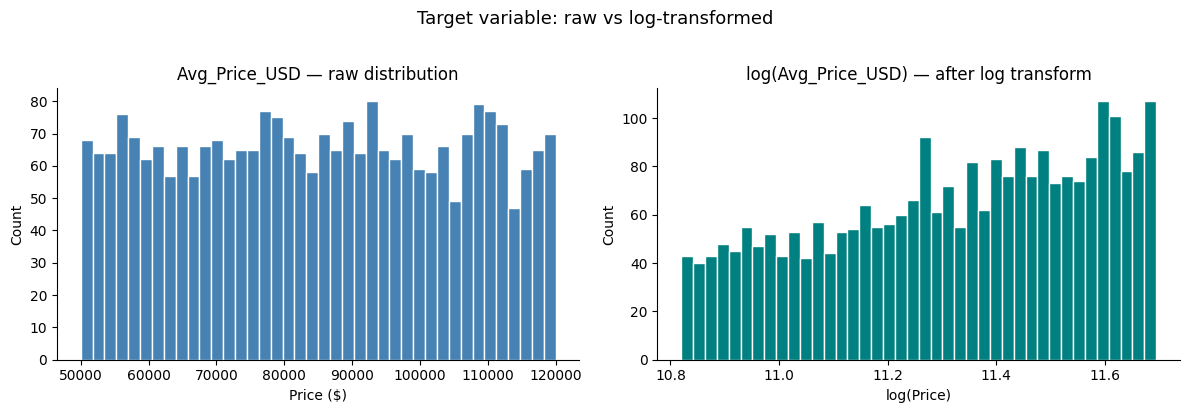

Note: log transform reduces right-skew — better for linear models.


In [7]:
# ── Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Avg_Price_USD'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Avg_Price_USD — raw distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Avg_Price_USD']), bins=40, color='teal', edgecolor='white')
axes[1].set_title('log(Avg_Price_USD) — after log transform')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target variable: raw vs log-transformed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Note: log transform reduces right-skew — better for linear models.')

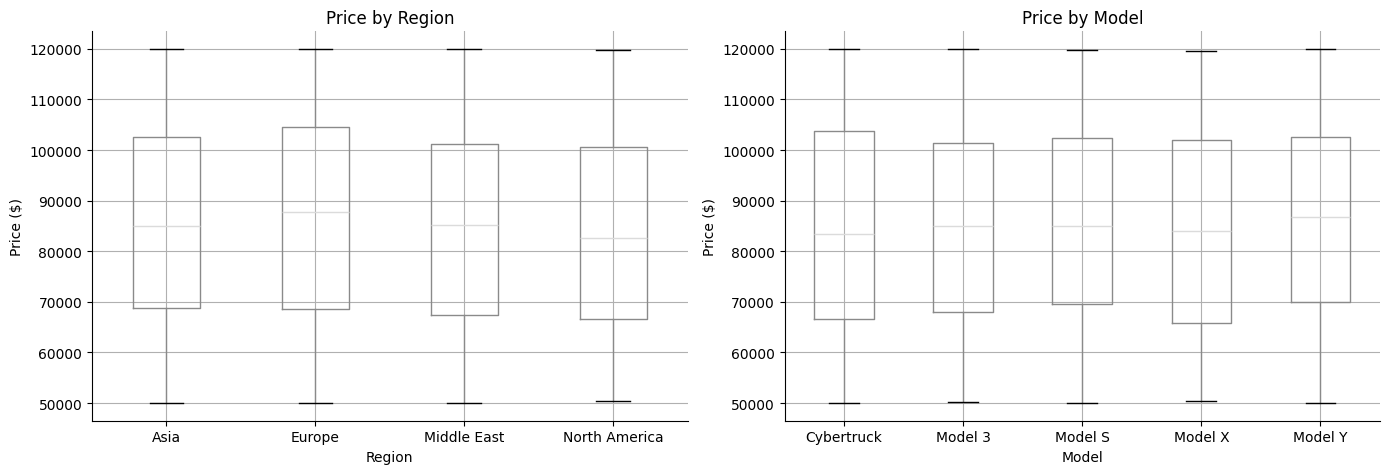

In [8]:
# ── Price by Region and Model ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Avg_Price_USD', by='Region', ax=axes[0])
axes[0].set_title('Price by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Price ($)')

df.boxplot(column='Avg_Price_USD', by='Model', ax=axes[1])
axes[1].set_title('Price by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Price ($)')

plt.suptitle('')
plt.tight_layout()
plt.show()

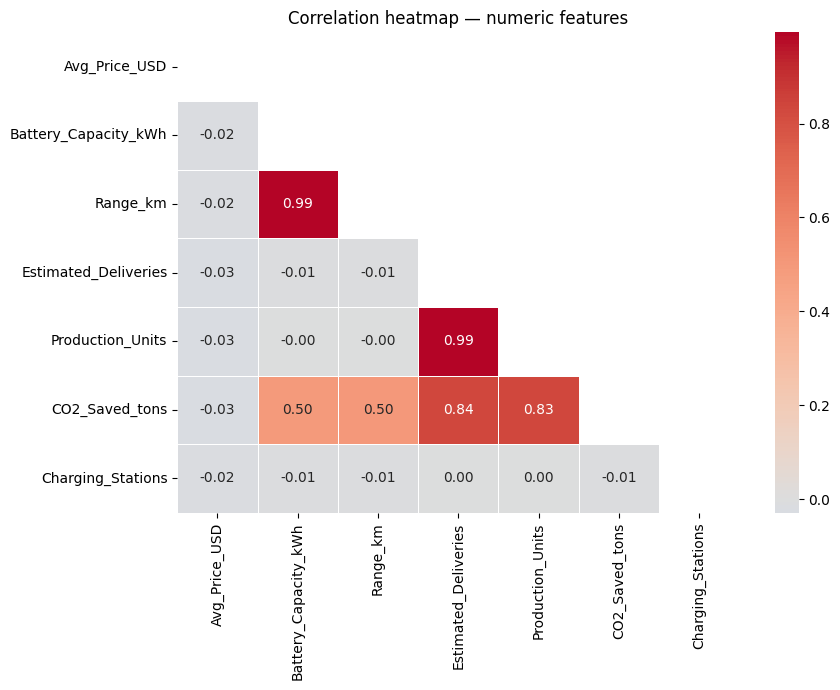

Key: values close to +1/-1 = strong linear relationship with target.


In [9]:
# ── Correlation heatmap (numeric features) ────────────────────────────────
num_cols = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'Estimated_Deliveries', 'Production_Units',
            'CO2_Saved_tons', 'Charging_Stations']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()
print('Key: values close to +1/-1 = strong linear relationship with target.')

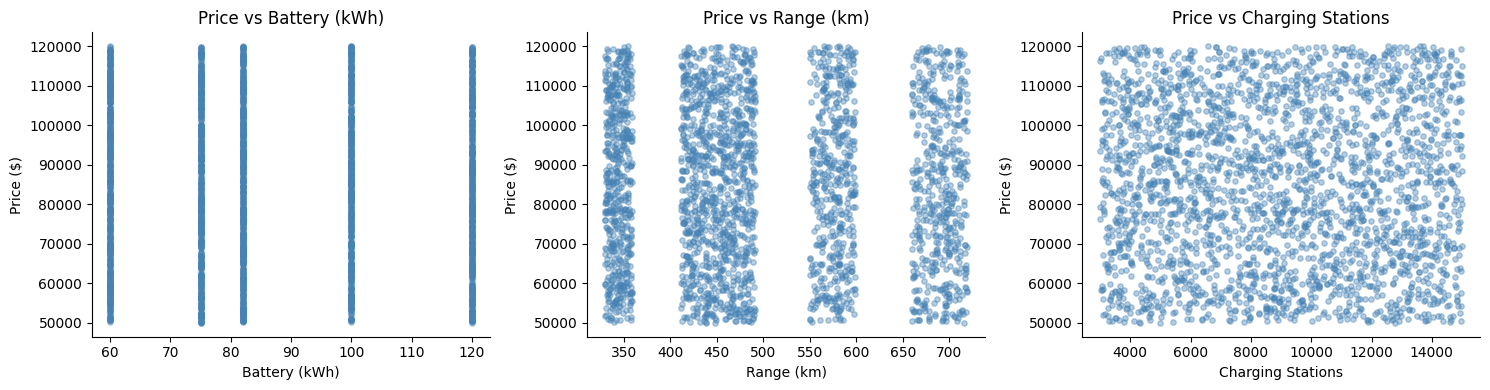

In [10]:
# ── Scatter plots: top numeric features vs price ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('Battery_Capacity_kWh', 'Battery (kWh)'),
         ('Range_km', 'Range (km)'),
         ('Charging_Stations', 'Charging Stations')]

for ax, (col, label) in zip(axes, pairs):
    ax.scatter(df[col], df['Avg_Price_USD'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'Price vs {label}')

plt.tight_layout()
plt.show()

---
## 4. Time Series Components & Stationarity
>

Our data has `Year` and `Month` columns — it has a time dimension.
Before treating it as plain tabular data, we should check for:
- **Trend**: Does price increase/decrease over time?
- **Seasonality**: Is there a repeating monthly pattern?
- **Stationarity**: Is the mean/variance stable over time? (Non-stationary data can mislead models.)



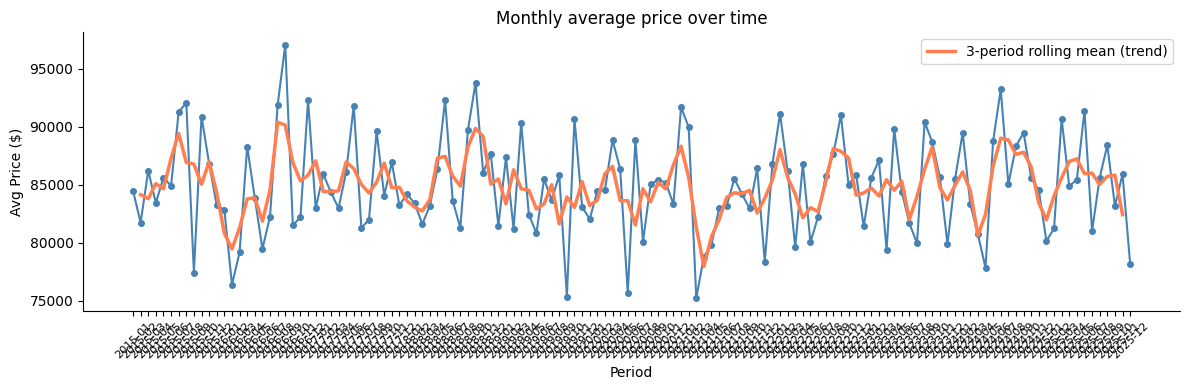

Rolling mean shows the underlying trend. Fluctuations around it = noise + seasonality.


In [11]:
# ── Monthly average price trend ───────────────────────────────────────────
df['YearMonth'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)
monthly_avg = df.groupby(['Year', 'Month'])['Avg_Price_USD'].mean().reset_index()
monthly_avg = monthly_avg.sort_values(['Year', 'Month'])
monthly_avg['Period'] = monthly_avg['Year'].astype(str) + '-' + \
                        monthly_avg['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 4))
plt.plot(monthly_avg['Period'], monthly_avg['Avg_Price_USD'],
         marker='o', linewidth=1.5, markersize=4, color='steelblue')

# Rolling mean to visualise trend
rolling = monthly_avg['Avg_Price_USD'].rolling(3, center=True).mean()
plt.plot(monthly_avg['Period'], rolling,
         linewidth=2.5, color='coral', label='3-period rolling mean (trend)')

plt.xticks(rotation=45, fontsize=8)
plt.title('Monthly average price over time')
plt.xlabel('Period')
plt.ylabel('Avg Price ($)')
plt.legend()
plt.tight_layout()
plt.show()
print('Rolling mean shows the underlying trend. Fluctuations around it = noise + seasonality.')

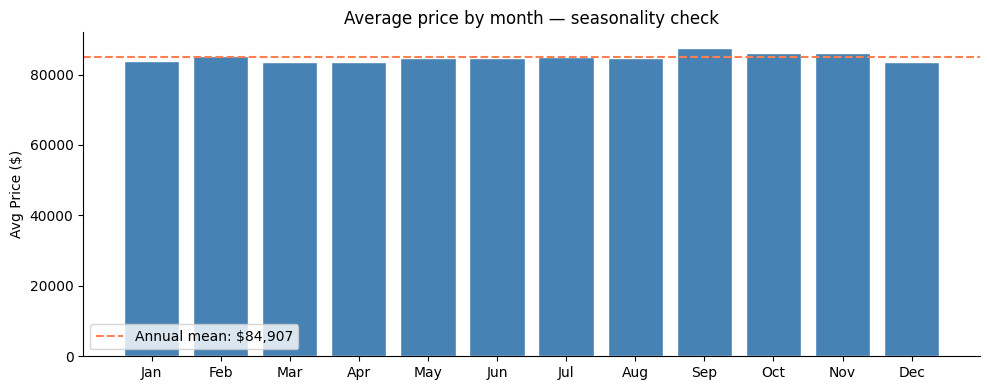

In [12]:
# ── Seasonality: average price by month ───────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df.groupby('Month')['Avg_Price_USD'].mean()

plt.figure(figsize=(10, 4))
plt.bar([month_names[i-1] for i in seasonal.index], seasonal.values,
        color='steelblue', edgecolor='white')
plt.axhline(seasonal.mean(), color='coral', linewidth=1.5,
            linestyle='--', label=f'Annual mean: ${seasonal.mean():,.0f}')
plt.title('Average price by month — seasonality check')
plt.ylabel('Avg Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

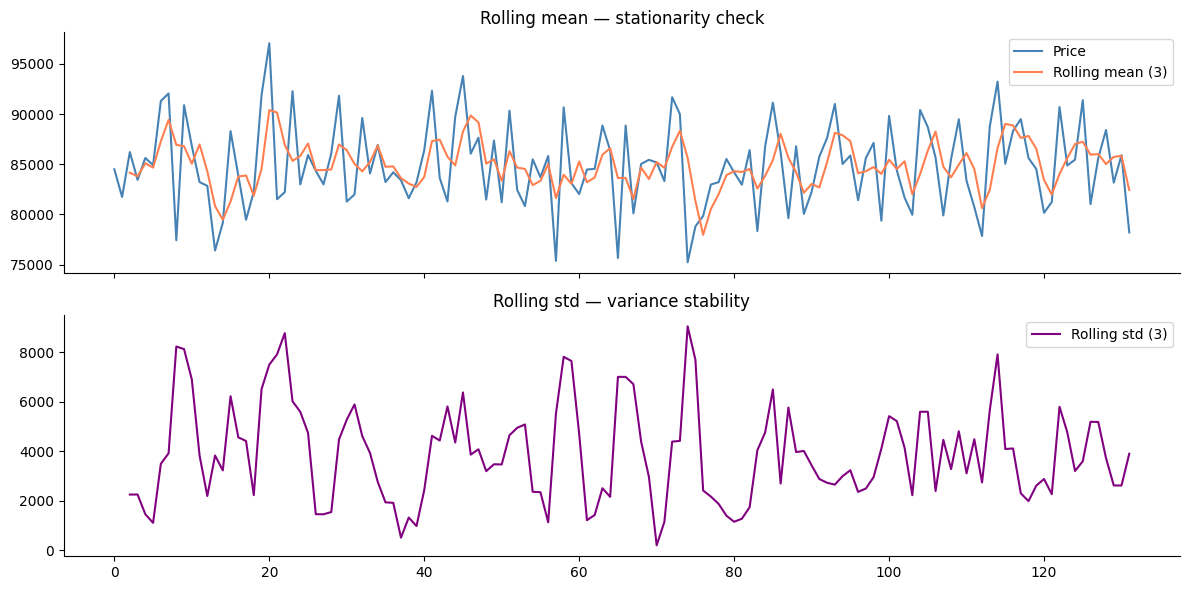

If rolling mean/std are roughly flat → series is likely stationary.
A visible upward/downward drift → non-stationary (would need differencing for time-series models).


In [13]:
# ── Stationarity: rolling mean and std ────────────────────────────────────
# A stationary series has constant mean & variance over time.
# We check this visually using a rolling window.
price_series = monthly_avg['Avg_Price_USD'].reset_index(drop=True)

roll_mean = price_series.rolling(window=3).mean()
roll_std  = price_series.rolling(window=3).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(price_series, label='Price', color='steelblue')
axes[0].plot(roll_mean, label='Rolling mean (3)', color='coral')
axes[0].set_title('Rolling mean — stationarity check')
axes[0].legend()

axes[1].plot(roll_std, label='Rolling std (3)', color='purple')
axes[1].set_title('Rolling std — variance stability')
axes[1].legend()

plt.tight_layout()
plt.show()
print('If rolling mean/std are roughly flat → series is likely stationary.')
print('A visible upward/downward drift → non-stationary (would need differencing for time-series models).')

---
## 5. Feature Engineering

We create new features that are more informative than the raw columns:

| New feature | Formula | Intuition |
|---|---|---|
| `Utilisation_Rate` | deliveries / production | Supply-demand pressure |
| `Season` | derived from Month | Quarterly demand cycles |
| `Is_Interpolated` | 1 if Source_Type contains 'Interpolated' | Data reliability signal |
| `Price_Per_kWh` | Price / Battery | Efficiency metric |
| `Range_Per_kWh` | Range / Battery | Energy efficiency |

In [14]:
# ── Feature engineering ───────────────────────────────────────────────────
df['Utilisation_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']

df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

df['Is_Interpolated'] = df['Source_Type'].str.contains('Interpolated').astype(int)

# These require Battery_Capacity_kWh to be non-null — will be filled in pipeline
df['Range_Per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh'].fillna(df['Battery_Capacity_kWh'].median())

print('Engineered features added:')
print(df[['Utilisation_Rate', 'Season', 'Is_Interpolated', 'Range_Per_kWh']].head(8))

Engineered features added:
   Utilisation_Rate  Season  Is_Interpolated  Range_Per_kWh
0          0.984600  Spring                1       5.866667
1          0.911864  Winter                0       5.840000
2          0.915334  Winter                1       5.853659
3          0.896594  Winter                0       5.933333
4          0.914087  Winter                0       5.508333
5          0.923260  Spring                0       5.817073
6          0.967528  Autumn                1       5.792683
7          0.914926  Summer                0       5.920000


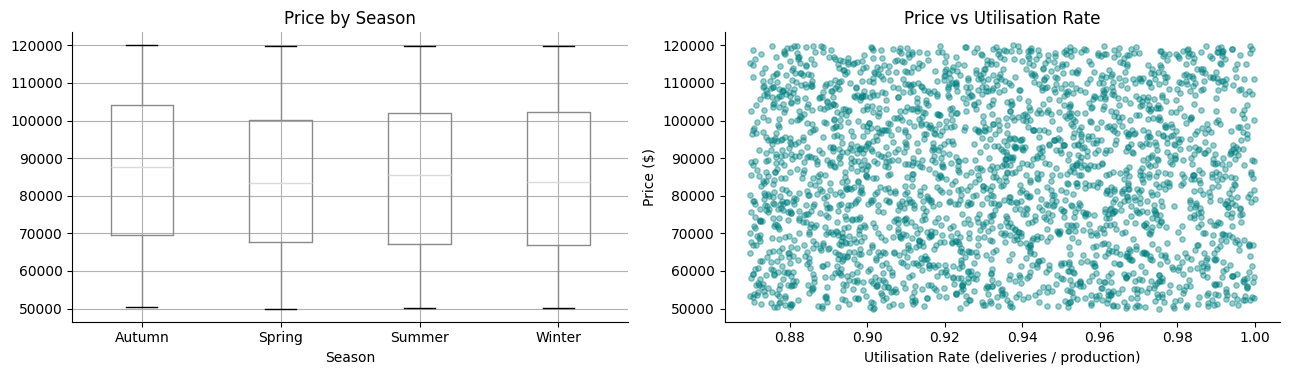

In [15]:
# ── Visualise engineered features ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='Avg_Price_USD', by='Season', ax=axes[0])
axes[0].set_title('Price by Season')
axes[0].set_xlabel('Season')
plt.sca(axes[0]); plt.title('Price by Season')

axes[1].scatter(df['Utilisation_Rate'], df['Avg_Price_USD'],
                alpha=0.4, s=15, color='teal')
axes[1].set_xlabel('Utilisation Rate (deliveries / production)')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price vs Utilisation Rate')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 6. Encoding & Feature Scaling


### Encoding
ML models need numbers. Categorical features are encoded:
- **One-hot encoding**: Creates a binary column per category. Used for `Region`, `Model`, `Season`.
- We use `drop='first'` to avoid the **dummy variable trap** (multicollinearity).

### Scaling
- **StandardScaler**: Transforms each numeric feature to mean=0, std=1.
- Important for Linear/Ridge/Lasso — they are sensitive to feature magnitude.

### Data Leakage
> **Data leakage** happens when information from the test set leaks into training.  
> **Wrong**: fit scaler on full dataset → split → test scores are too optimistic.  
> **Right**: split first → fit scaler ONLY on train → transform both train and test.
> 
> We handle this automatically with `sklearn.Pipeline` in the next section.

In [16]:
# ── Define feature columns & train/test split ────────────────────────────
TARGET = 'Avg_Price_USD'

drop_cols = [TARGET, 'YearMonth', 'Source_Type']
feature_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

numeric_features = [
    'Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Charging_Stations', 'Utilisation_Rate', 'Is_Interpolated', 'Range_Per_kWh'
]
categorical_features = ['Region', 'Model', 'Season']

# Keep only columns that actually exist in the dataframe
numeric_features     = [c for c in numeric_features     if c in feature_df.columns]
categorical_features = [c for c in categorical_features if c in feature_df.columns]

X = feature_df[numeric_features + categorical_features]
y = df[TARGET]   # raw USD — TransformedTargetRegressor handles log internally

# Sort by time BEFORE split so TimeSeriesSplit sees sequential order
sort_cols = [c for c in ['Year', 'Month'] if c in X.columns]
if sort_cols:
    sort_idx = df[sort_cols].sort_values(sort_cols).index
    X, y = X.loc[sort_idx].reset_index(drop=True), y.loc[sort_idx].reset_index(drop=True)

# 80/20 split — keep temporal order (no shuffle) when time data is present
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Features: {X.shape[1]} ({len(numeric_features)} numeric, {len(categorical_features)} categorical)')
print(f'Target: raw USD (log transform handled inside TransformedTargetRegressor)')


Train: 2112 rows | Test: 528 rows
Features: 14 (11 numeric, 3 categorical)
Target: raw USD (log transform handled inside TransformedTargetRegressor)


---
## 7. sklearn Pipeline

A `Pipeline` chains steps so preprocessing and modelling happen together — safely.

```
ColumnTransformer
  ├── Numeric: Impute (median) → StandardScaler
  └── Categorical: Impute (most_frequent) → OneHotEncoder
           ↓
      ML Model
```

When we call `pipeline.fit(X_train, y_train)`, **only** `X_train` is used to fit the imputer and scaler.
When we call `pipeline.predict(X_test)`, the same fitted transforms are applied to test data — **no leakage**.

In [17]:
# ── Preprocessing pipeline ───────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # handle_unknown='ignore' → unseen categories (new region/model) get all-zero row
    # instead of crashing. sparse_output=False → plain numpy array.
    ('onehot',  OneHotEncoder(drop='first',
                               handle_unknown='ignore',
                               sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'   # explicitly drop any unlisted columns — no silent passthrough
)

print('Preprocessor built:')
print(f'  Numeric  : {numeric_features}')
print(f'  Categoric: {categorical_features}')
print(f'  remainder: drop (explicit)')


Preprocessor built:
  Numeric  : ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Utilisation_Rate', 'Is_Interpolated', 'Range_Per_kWh']
  Categoric: ['Region', 'Model', 'Season']
  remainder: drop (explicit)


---
## 8. Models — Linear Regression, Ridge (L2), Lasso (L1)

### Bias-Variance Tradeoff
- **High bias (underfitting)**: Model is too simple, misses patterns in training data too.
- **High variance (overfitting)**: Model memorises training data, fails on new data.
- **Goal**: Find the sweet spot.

| Model | Regularisation | Effect |
|---|---|---|
| Linear Regression | None | Can overfit with many features |
| Ridge (L2) | Shrinks all coefficients | Reduces variance, handles multicollinearity |
| Lasso (L1) | Can zero-out coefficients | Feature selection + regularisation |

In [18]:
# ── Build models wrapped in TransformedTargetRegressor ───────────────────
# TransformedTargetRegressor applies np.log1p to y BEFORE training
# and np.expm1 AFTER predicting — so metrics are always in real USD.
# This prevents the 'tiny MAE' trap from evaluating on log scale.

def make_model(estimator):
    base = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1
    )

# Note: LinearRegression has no random_state. Ridge/Lasso accept random_state
# but it only affects the solver selection, not results — set for reproducibility.
fitted_models = {
    'Linear Regression': make_model(LinearRegression()),
    'Ridge (L2)':        make_model(Ridge(alpha=1.0, random_state=GLOBAL_SEED)),
    'Lasso (L1)':        make_model(Lasso(alpha=0.001, max_iter=10000, random_state=GLOBAL_SEED))
}

for name, pipe in fitted_models.items():
    pipe.fit(X_train, y_train)
    print(f'{name}: trained ✓')

print('\nAll models output real USD predictions (log transform internal).')


Linear Regression: trained ✓
Ridge (L2): trained ✓
Lasso (L1): trained ✓

All models output real USD predictions (log transform internal).


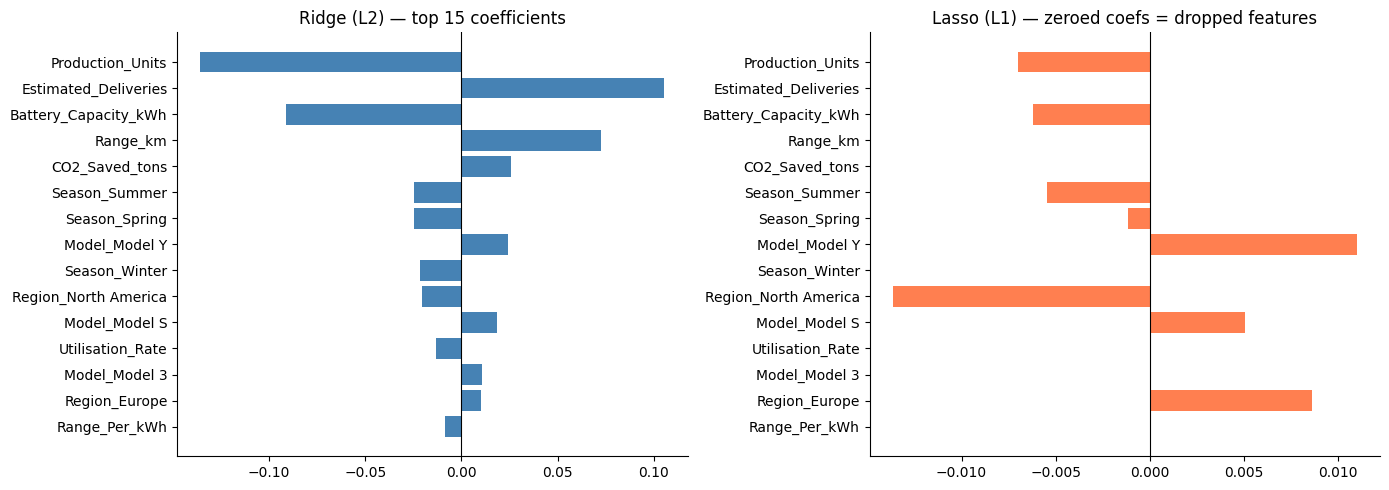

Lasso zeroed out 9/21 features (feature selection).


In [19]:
# ── Compare Ridge vs Lasso coefficients ──────────────────────────────────
# fitted_models values are TransformedTargetRegressor objects.
# The actual sklearn Pipeline lives inside .regressor_
# Then .named_steps['preprocessor'] and .named_steps['model'] work as normal.

ridge_inner = fitted_models['Ridge (L2)'].regressor_
lasso_inner = fitted_models['Lasso (L1)'].regressor_

# Get feature names from the fitted OneHotEncoder inside the preprocessor
cat_encoder   = ridge_inner.named_steps['preprocessor'] \
                            .named_transformers_['cat'] \
                            .named_steps['onehot']
cat_names     = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_names

ridge_coefs = ridge_inner.named_steps['model'].coef_
lasso_coefs = lasso_inner.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge':   ridge_coefs,
    'Lasso':   lasso_coefs
})
coef_df['Abs_Ridge'] = np.abs(ridge_coefs)
coef_df = coef_df.sort_values('Abs_Ridge', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(coef_df['Feature'], coef_df['Ridge'], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Ridge (L2) — top 15 coefficients')
axes[0].invert_yaxis()

axes[1].barh(coef_df['Feature'], coef_df['Lasso'], color='coral')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Lasso (L1) — zeroed coefs = dropped features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

lasso_zeros = (lasso_coefs == 0).sum()
print(f'Lasso zeroed out {lasso_zeros}/{len(lasso_coefs)} features (feature selection).')


---
## 9. Evaluation Metrics + Cross Validation

### Metrics for regression
| Metric | Formula | Interpretation |
|---|---|---|
| **R²** | 1 - SS_res/SS_tot | % variance explained. 1.0 = perfect, 0 = baseline mean |
| **MAE** | mean(|y - ŷ|) | Average error in original units. Easy to interpret |
| **RMSE** | √mean((y - ŷ)²) | Penalises large errors more than MAE |

### Cross Validation (K-Fold)
A single train/test split can be lucky or unlucky. **K-Fold CV** trains and evaluates on K different splits, giving a more reliable performance estimate.

In [20]:
# ── Evaluation on test set — real USD metrics ────────────────────────────
# TransformedTargetRegressor.predict() already returns real USD.
# No manual expm1 needed here — metrics are directly interpretable.

def evaluate(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)          # already in USD
    return {
        'Model':    name,
        'R²':       round(r2_score(y_te, y_pred), 4),
        'MAE ($)':  round(mean_absolute_error(y_te, y_pred), 0),
        'RMSE ($)': round(np.sqrt(mean_squared_error(y_te, y_pred)), 0)
    }

eval_rows = [evaluate(name, pipe, X_test, y_test)
             for name, pipe in fitted_models.items()]
eval_df = pd.DataFrame(eval_rows)
print(eval_df.to_string(index=False))
print('\nAll errors are in real USD — no log-scale distortion.')


            Model      R²  MAE ($)  RMSE ($)
Linear Regression -0.0233  17277.0   20092.0
       Ridge (L2) -0.0234  17287.0   20093.0
       Lasso (L1) -0.0245  17340.0   20104.0

All errors are in real USD — no log-scale distortion.


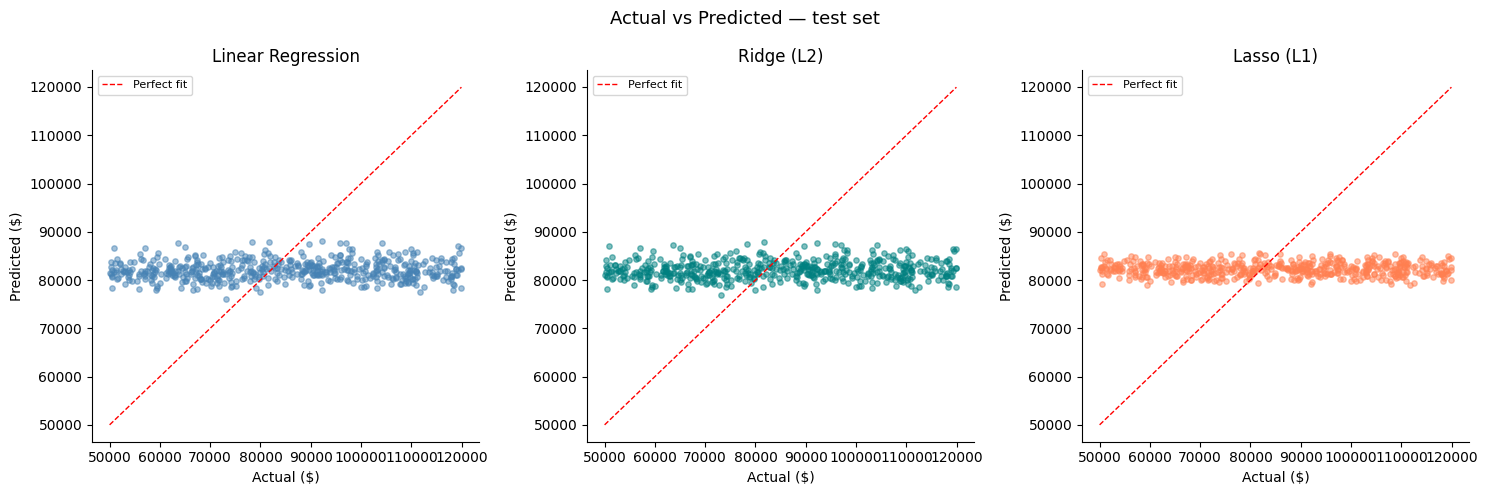

In [21]:
# ── Actual vs Predicted — all three models ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'teal', 'coral']

for ax, (name, pipe), col in zip(axes, fitted_models.items(), colors):
    y_pred = pipe.predict(X_test)   # already real USD
    ax.scatter(y_test, y_pred, alpha=0.5, s=15, color=col)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — test set', fontsize=13)
plt.tight_layout()
plt.show()


In [22]:
# ── TimeSeriesSplit Cross Validation ─────────────────────────────────────
# Data has Year+Month → future info must not leak into past predictions.
# TimeSeriesSplit respects temporal order:
#   Fold 1: train[0:n]   test[n:n+k]
#   Fold 2: train[0:n+k] test[n+k:n+2k]  etc.
# KFold(shuffle=True) would randomly mix 2023 data into 2020 training — wrong.

tscv = TimeSeriesSplit(n_splits=5)

print('TimeSeriesSplit Cross Validation — R² scores\n')
for name, pipe in fitted_models.items():
    scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  '
          f'folds={[round(s,3) for s in scores]}')

print('\nHigh std across folds = model unstable over time.')
print('Negative R² in early folds = model trained on too little data.')


TimeSeriesSplit Cross Validation — R² scores

Linear Regression          mean=-0.0428  std=0.0213  folds=[np.float64(-0.076), np.float64(-0.026), np.float64(-0.034), np.float64(-0.059), np.float64(-0.019)]
Ridge (L2)                 mean=-0.0424  std=0.0206  folds=[np.float64(-0.073), np.float64(-0.026), np.float64(-0.034), np.float64(-0.06), np.float64(-0.019)]
Lasso (L1)                 mean=-0.0348  std=0.0160  folds=[np.float64(-0.055), np.float64(-0.021), np.float64(-0.026), np.float64(-0.054), np.float64(-0.019)]

High std across folds = model unstable over time.
Negative R² in early folds = model trained on too little data.


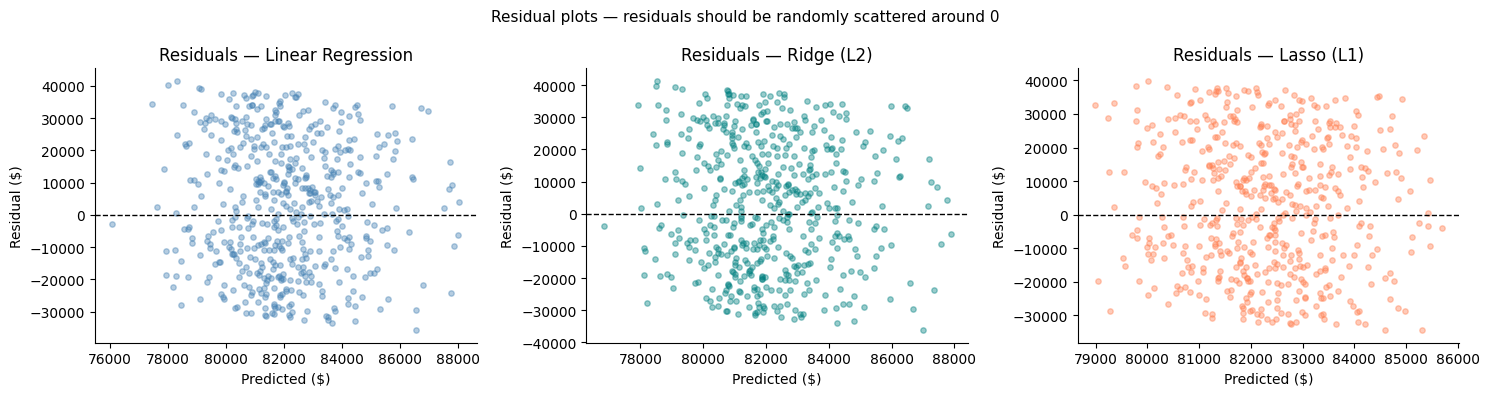

In [23]:
# ── Residual plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe), col in zip(axes, fitted_models.items(), colors):
    y_pred = pipe.predict(X_test)
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color=col)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted ($)')
    ax.set_ylabel('Residual ($)')
    ax.set_title(f'Residuals — {name}')

plt.suptitle('Residual plots — residuals should be randomly scattered around 0', fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning (GridSearchCV)

**Hyperparameters** are settings you choose before training (not learned from data).  
For Ridge and Lasso, the key hyperparameter is **alpha (λ)**:
- Higher alpha → stronger regularisation → simpler model (more bias, less variance)
- Lower alpha → weaker regularisation → closer to plain linear regression

**GridSearchCV** tries every combination in a grid and picks the best using cross-validation — **never touching the test set**.

Ridge param keys: ['check_inverse', 'func', 'inverse_func', 'regressor__memory', 'regressor__steps', 'regressor__transform_input', 'regressor__verbose', 'regressor__preprocessor', 'regressor__model', 'regressor__preprocessor__force_int_remainder_cols', 'regressor__preprocessor__n_jobs', 'regressor__preprocessor__remainder', 'regressor__preprocessor__sparse_threshold', 'regressor__preprocessor__transformer_weights', 'regressor__preprocessor__transformers', 'regressor__preprocessor__verbose', 'regressor__preprocessor__verbose_feature_names_out', 'regressor__preprocessor__num', 'regressor__preprocessor__cat', 'regressor__preprocessor__num__memory', 'regressor__preprocessor__num__steps', 'regressor__preprocessor__num__transform_input', 'regressor__preprocessor__num__verbose', 'regressor__preprocessor__num__imputer', 'regressor__preprocessor__num__scaler', 'regressor__preprocessor__num__imputer__add_indicator', 'regressor__preprocessor__num__imputer__copy', 'regressor__preprocessor__num__im

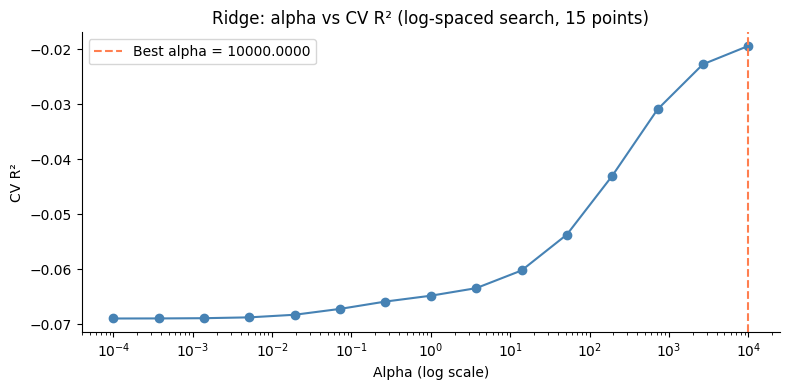

In [24]:
# ── GridSearchCV: Ridge — log-spaced alpha ───────────────────────────────
ridge_base = Pipeline([('preprocessor', preprocessor),
                        ('model', Ridge(random_state=GLOBAL_SEED))])
ridge_ttr  = TransformedTargetRegressor(
    regressor=ridge_base, func=np.log1p, inverse_func=np.expm1
)

# Verify exact param key names at runtime
print('Ridge param keys:', list(ridge_ttr.get_params().keys()))

# Structure: TransformedTargetRegressor → regressor (Pipeline) → model (Ridge) → alpha
ridge_param_grid = {
    'regressor__model__alpha': np.logspace(-4, 4, 15)
}

ridge_gs = GridSearchCV(
    ridge_ttr, ridge_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2', n_jobs=-1
)
ridge_gs.fit(X_train, y_train)

best_alpha = ridge_gs.best_params_['regressor__model__alpha']
print(f'Best Ridge alpha : {best_alpha}')
print(f'Best CV R²       : {ridge_gs.best_score_:.4f}')

ridge_cv = pd.DataFrame(ridge_gs.cv_results_)
alphas   = [p['regressor__model__alpha'] for p in ridge_gs.cv_results_['params']]

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, ridge_cv['mean_test_score'], marker='o', color='steelblue')
plt.axvline(best_alpha, color='coral', linestyle='--',
            label=f'Best alpha = {best_alpha:.4f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV R²')
plt.title('Ridge: alpha vs CV R² (log-spaced search, 15 points)')
plt.legend()
plt.tight_layout()
plt.show()


Lasso param keys: ['check_inverse', 'func', 'inverse_func', 'regressor__memory', 'regressor__steps', 'regressor__transform_input', 'regressor__verbose', 'regressor__preprocessor', 'regressor__model', 'regressor__preprocessor__force_int_remainder_cols', 'regressor__preprocessor__n_jobs', 'regressor__preprocessor__remainder', 'regressor__preprocessor__sparse_threshold', 'regressor__preprocessor__transformer_weights', 'regressor__preprocessor__transformers', 'regressor__preprocessor__verbose', 'regressor__preprocessor__verbose_feature_names_out', 'regressor__preprocessor__num', 'regressor__preprocessor__cat', 'regressor__preprocessor__num__memory', 'regressor__preprocessor__num__steps', 'regressor__preprocessor__num__transform_input', 'regressor__preprocessor__num__verbose', 'regressor__preprocessor__num__imputer', 'regressor__preprocessor__num__scaler', 'regressor__preprocessor__num__imputer__add_indicator', 'regressor__preprocessor__num__imputer__copy', 'regressor__preprocessor__num__im

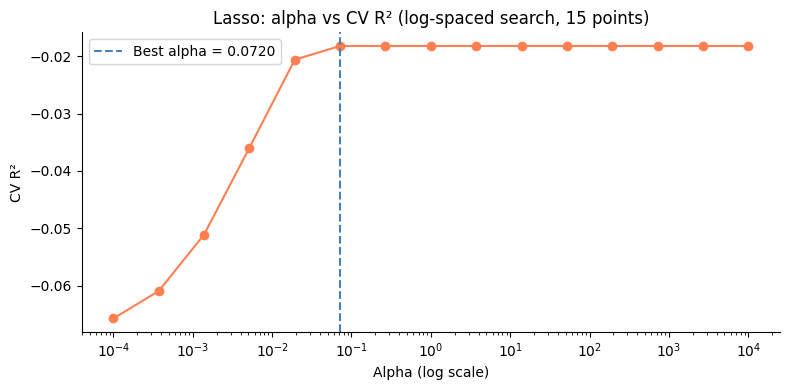

In [25]:
# ── GridSearchCV: Lasso — log-spaced alpha ───────────────────────────────
lasso_base = Pipeline([('preprocessor', preprocessor),
                        ('model', Lasso(max_iter=10000, random_state=GLOBAL_SEED))])
lasso_ttr  = TransformedTargetRegressor(
    regressor=lasso_base, func=np.log1p, inverse_func=np.expm1
)

# Verify exact param key names at runtime
print('Lasso param keys:', list(lasso_ttr.get_params().keys()))

# Structure: TransformedTargetRegressor → regressor (Pipeline) → model (Lasso) → alpha
lasso_param_grid = {
    'regressor__model__alpha': np.logspace(-4, 4, 15)
}

lasso_gs = GridSearchCV(
    lasso_ttr, lasso_param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2', n_jobs=-1
)
lasso_gs.fit(X_train, y_train)

best_alpha_l = lasso_gs.best_params_['regressor__model__alpha']
print(f'Best Lasso alpha : {best_alpha_l}')
print(f'Best CV R²       : {lasso_gs.best_score_:.4f}')

lasso_cv = pd.DataFrame(lasso_gs.cv_results_)
alphas_l = [p['regressor__model__alpha'] for p in lasso_gs.cv_results_['params']]

plt.figure(figsize=(8, 4))
plt.semilogx(alphas_l, lasso_cv['mean_test_score'], marker='o', color='coral')
plt.axvline(best_alpha_l, color='steelblue', linestyle='--',
            label=f'Best alpha = {best_alpha_l:.4f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV R²')
plt.title('Lasso: alpha vs CV R² (log-spaced search, 15 points)')
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
# ── Final comparison — tuned models on test set ──────────────────────────
tuned_models = {
    'Linear Regression': fitted_models['Linear Regression'],
    'Ridge (tuned)':     ridge_gs.best_estimator_,
    'Lasso (tuned)':     lasso_gs.best_estimator_
}

final_rows = [evaluate(name, pipe, X_test, y_test)
              for name, pipe in tuned_models.items()]
final_df = pd.DataFrame(final_rows)
print('Final test-set performance (real USD, tuned models):\n')
print(final_df.to_string(index=False))

best = final_df.loc[final_df['R²'].idxmax(), 'Model']
print(f'\n✅ Best model: {best}')
print('MAE and RMSE are in real USD — e.g. MAE of 5000 means $5,000 average error.')


Final test-set performance (real USD, tuned models):

            Model      R²  MAE ($)  RMSE ($)
Linear Regression -0.0233  17277.0   20092.0
    Ridge (tuned) -0.0210  17354.0   20069.0
    Lasso (tuned) -0.0198  17352.0   20057.0

✅ Best model: Lasso (tuned)
MAE and RMSE are in real USD — e.g. MAE of 5000 means $5,000 average error.
